# 05 — Model Training

## Why this step exists

We now have a model-ready feature table from Notebook 04. This notebook
trains several candidate models and picks a train/test split that respects
**time order** - a critical detail for any forecasting problem.

## Why NOT a random train/test split

A normal `train_test_split(shuffle=True)` would randomly scatter dates
between train and test. That means we could train on a day in **March 2011**
and test on a day in **January 2010** - i.e. train on the future, test on
the past. In real deployment we will never have future data available when
predicting - so testing this way would give a falsely optimistic score that
collapses in production.

Instead, `model.time_based_split()` splits chronologically: the earliest
80% of days train the model, the most recent 20% test it - simulating how
the model will actually be used.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from ecommerce_sales_analysis.model import time_based_split, train_models, evaluate_models, get_models

features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)
print(f"Feature table: {features.shape}")

X_train, X_test, y_train, y_test = time_based_split(features, test_size=0.2)
print(f"Train: {len(X_train)} days ({X_train.index.min().date()} to {X_train.index.max().date()})")
print(f"Test:  {len(X_test)} days ({X_test.index.min().date()} to {X_test.index.max().date()})")

assert X_train.index.max() < X_test.index.min(), "Train must end before test begins"
print("\nConfirmed: no time leakage between train and test sets.")

Feature table: (709, 16)
Train: 567 days (2009-12-31 to 2011-07-20)
Test:  142 days (2011-07-21 to 2011-12-09)

Confirmed: no time leakage between train and test sets.


## Candidate models

We train three models of increasing complexity, defined in `model.get_models()`:

| Model | Why include it |
|---|---|
| **Linear Regression** | Simplest real model - fast, interpretable, our sanity floor above the naive baseline |
| **Random Forest** | Captures non-linear patterns and feature interactions automatically |
| **Gradient Boosting** | Usually the strongest tabular-data performer; learns from residual errors iteratively |

We also compare against a **naive baseline** (predict today = yesterday's
revenue). If our real models can't beat this trivial rule, they're not
earning their complexity.

In [2]:
fitted_models = train_models(X_train, y_train)
print(f"Trained {len(fitted_models)} models: {list(fitted_models.keys())}")

Trained 3 models: ['LinearRegression', 'RandomForest', 'GradientBoosting']


In [3]:
results = evaluate_models(fitted_models, X_test, y_test)
results

,MAE,RMSE,MAPE
RandomForest,9700.318320,17663.936800,32.447958
GradientBoosting,9923.444624,18172.788715,33.054296
LinearRegression,11587.602248,18537.046543,32.687784
Baseline (naive lag-1),20095.526056,26594.034198,55.595973


**Reading these metrics:**
- **MAE** (Mean Absolute Error): average error in GBP - "on average we're off by £X"
- **RMSE** (Root Mean Squared Error): like MAE but penalizes big misses harder
- **MAPE** (Mean Absolute Percentage Error): error as a % of actual revenue - comparable across quiet vs busy days

Lower is better for all three. The table is sorted best (lowest RMSE) first.

In [4]:
best_model_name = results.index[0]
if best_model_name.startswith('Baseline'):
    print('WARNING: no trained model beat the naive baseline - investigate features/hyperparameters.')
else:
    baseline_rmse = results.loc['Baseline (naive lag-1)', 'RMSE']
    best_rmse = results.loc[best_model_name, 'RMSE']
    improvement = (1 - best_rmse / baseline_rmse) * 100
    print(f"Best model: {best_model_name}")
    print(f"RMSE improvement over naive baseline: {improvement:.1f}%")

Best model: RandomForest
RMSE improvement over naive baseline: 33.6%


## Visualizing predictions vs actuals on the test period

C:\Users\panch\AppData\Local\Temp\ipykernel_13316\1582497420.py:6: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(X_test.index, preds, label=f'{name} (predicted)', alpha=0.7)


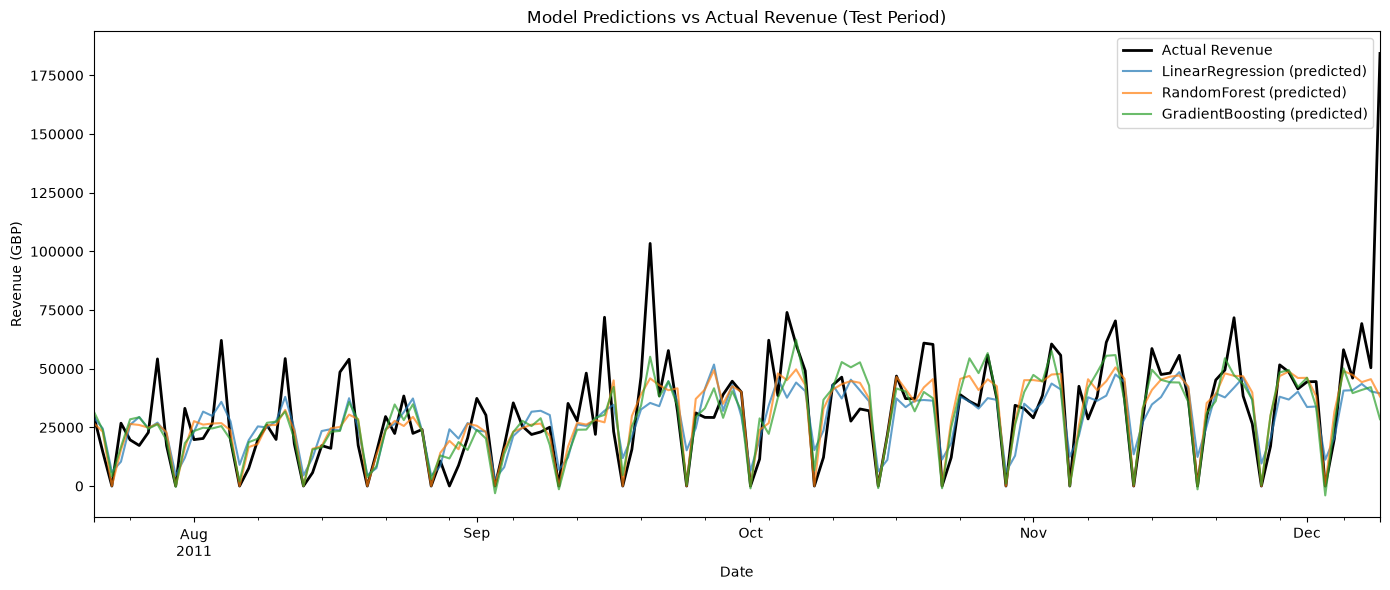

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
y_test.plot(ax=ax, label='Actual Revenue', color='black', linewidth=2)

for name, model in fitted_models.items():
    preds = model.predict(X_test)
    ax.plot(X_test.index, preds, label=f'{name} (predicted)', alpha=0.7)

ax.set_title('Model Predictions vs Actual Revenue (Test Period)')
ax.set_ylabel('Revenue (GBP)')
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance (Random Forest)

Which features actually drive the Random Forest's predictions? This tells
us whether the model is relying on sensible signals (recent lags, rolling
trend) or something suspicious.

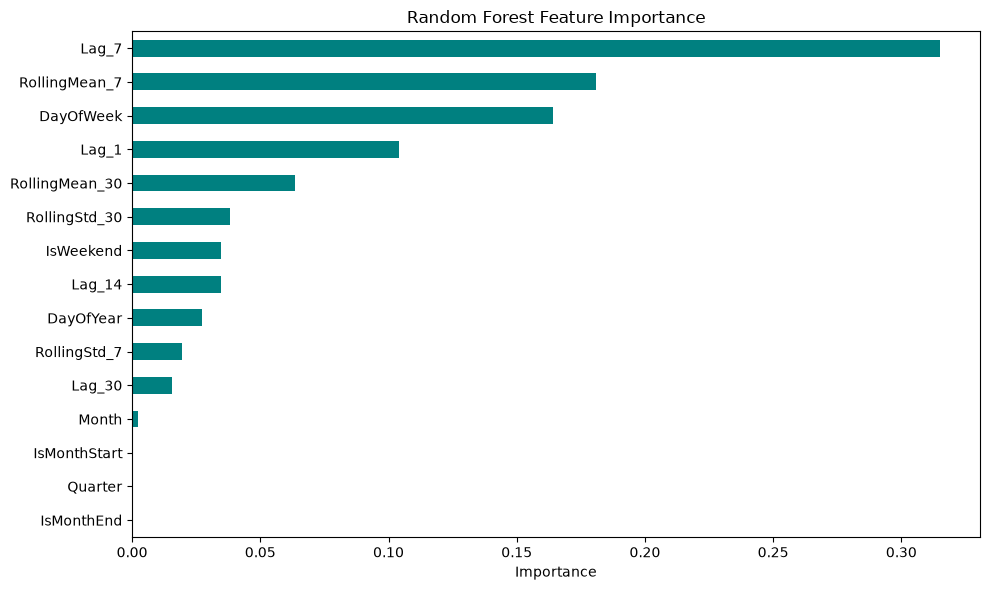

Lag_7             0.314920
RollingMean_7     0.180815
DayOfWeek         0.164183
Lag_1             0.103921
RollingMean_30    0.063387
RollingStd_30     0.038062
IsWeekend         0.034551
Lag_14            0.034507
DayOfYear         0.027141
RollingStd_7      0.019466
Lag_30            0.015718
Month             0.002406
IsMonthStart      0.000373
Quarter           0.000354
IsMonthEnd        0.000195
dtype: float64

In [6]:
rf_model = fitted_models['RandomForest']
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

importances.plot(kind='barh', figsize=(10, 6), color='teal', title='Random Forest Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

In [7]:
# Save the best model and the evaluation results for Notebook 06 (Evaluation)
# and Notebook 07 (Prediction & Report)
import pickle
from pathlib import Path

models_dir = Path('../data/processed')
with open(models_dir / 'trained_models.pkl', 'wb') as f:
    pickle.dump(fitted_models, f)

results.to_csv(models_dir / 'model_results.csv')
print(f"Saved {len(fitted_models)} trained models and results table to {models_dir}")

Saved 3 trained models and results table to ..\data\processed


## What we learned

_Fill this in after running the cells above:_
- Which model performed best, and by how much versus the naive baseline?
- Do the top feature importances make intuitive sense (recent lags/rolling
  means should dominate over something like DayOfYear)?
- Looking at the predictions-vs-actual chart, are there periods where every
  model struggles (e.g. sudden spikes)?

Next: **Notebook 06 - Model Evaluation**, where we dig deeper into the
best model's errors (residual analysis, where it over/under-predicts).